In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score)
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# LOAD

df = pd.read_csv("thermal_features.csv")
print(f"Dataset shape: {df.shape}")
print(f"Label distribution:\n{df['label'].value_counts()}\n")


Dataset shape: (8942, 12)
Label distribution:
label
Control    4490
DM         4452
Name: count, dtype: int64



In [3]:
#Encode Labels

le = LabelEncoder()
df["label_enc"] = le.fit_transform(df["label"])
print(f"Classes: {list(le.classes_)} → {list(range(len(le.classes_)))}\n")

Classes: ['Control', 'DM'] → [0, 1]



In [4]:
# Features and Target

FEATURE_COLS = [
    "mean_temp", "max_temp", "std_temp", "range_temp",
    "hot_spot_count", "temp_gradient",
    "glcm_contrast", "glcm_homogeneity", "glcm_entropy"
]

X = df[FEATURE_COLS].values
y = df["label_enc"].values

print(f"Feature matrix: {X.shape}")
print(f"Any NaNs: {np.isnan(X).sum()}\n")


Feature matrix: (8942, 9)
Any NaNs: 0



In [6]:
# Single Split (Sanity check)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}\n")

Train size: 7153 | Test size: 1789



In [7]:
# Train Random Forest

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=4,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', min_samples_leaf=2,
                       min_samples_split=4, n_estimators=200, n_jobs=-1,
                       random_state=42)

In [8]:
# Sample Evaluation

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy : {acc * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

if len(le.classes_) == 2:
    auc = roc_auc_score(y_test, y_prob[:, 1])
    print(f"ROC-AUC  : {auc:.4f}\n")
else:
    auc = roc_auc_score(y_test, y_prob, multi_class="ovr", average="macro")
    print(f"ROC-AUC (macro-OvR): {auc:.4f}\n")

Accuracy : 96.25%

Classification Report:
              precision    recall  f1-score   support

     Control       0.95      0.98      0.96       898
          DM       0.98      0.94      0.96       891

    accuracy                           0.96      1789
   macro avg       0.96      0.96      0.96      1789
weighted avg       0.96      0.96      0.96      1789

ROC-AUC  : 0.9936



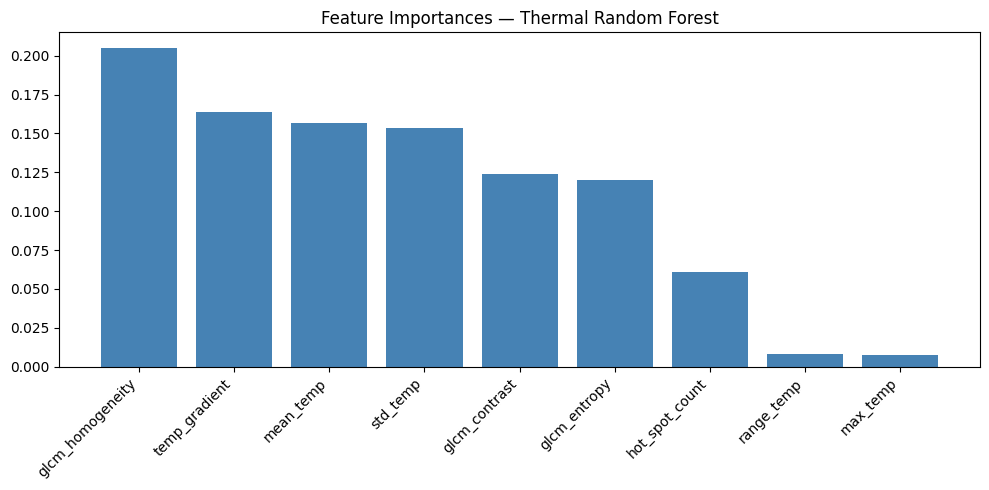


Top 3 most predictive features:
  1. glcm_homogeneity — 0.2048
  2. temp_gradient — 0.1637
  3. mean_temp — 0.1566

Thermal RF pipeline verified end-to-end.


In [9]:
# Feature Importance

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(len(FEATURE_COLS)),
        importances[indices], color="steelblue")
plt.xticks(range(len(FEATURE_COLS)),
           [FEATURE_COLS[i] for i in indices], rotation=45, ha="right")
plt.title("Feature Importances — Thermal Random Forest")
plt.tight_layout()
plt.savefig("thermal_rf_feature_importance.png", dpi=150)
plt.show()

print("\nTop 3 most predictive features:")
for i in range(3):
    print(f"  {i+1}. {FEATURE_COLS[indices[i]]} — {importances[indices[i]]:.4f}")

print("\nThermal RF pipeline verified end-to-end.")

In [10]:
!pip install optuna -q

import optuna
from sklearn.model_selection import cross_val_score, GridSearchCV
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Optuna objective ──────────────────────────────────────────────────────────

def rf_objective(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 100, 600),
        "max_depth":        trial.suggest_int("max_depth", 3, 20),
        "min_samples_split":trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 8),
        "max_features":     trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "class_weight":     "balanced",
        "random_state":     42,
        "n_jobs":           -1,
    }
    clf = RandomForestClassifier(**params)
    score = cross_val_score(clf, X_train, y_train, cv=3,
                            scoring="roc_auc", n_jobs=-1).mean()
    return score

study_rf = optuna.create_study(direction="maximize")
study_rf.optimize(rf_objective, n_trials=50, show_progress_bar=True)

print(f"\nBest ROC-AUC (CV): {study_rf.best_value:.4f}")
print(f"Best params: {study_rf.best_params}")

# ── Refit on full train set with best params ──────────────────────────────────

best_rf = RandomForestClassifier(**study_rf.best_params,
                                  class_weight="balanced",
                                  random_state=42, n_jobs=-1)
best_rf.fit(X_train, y_train)

y_pred_opt = best_rf.predict(X_test)
y_prob_opt = best_rf.predict_proba(X_test)

print(f"\nOptuna-tuned RF — Test Accuracy: {accuracy_score(y_test, y_pred_opt)*100:.2f}%")
print(classification_report(y_test, y_pred_opt, target_names=le.classes_))

if len(le.classes_) == 2:
    print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_opt[:,1]):.4f}")
else:
    print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_opt, multi_class='ovr', average='macro'):.4f}")

# ── GridSearch around Optuna best region ──────────────────────────────────────

bp = study_rf.best_params
grid_params = {
    "n_estimators":      [max(50, bp["n_estimators"]-100), bp["n_estimators"], bp["n_estimators"]+100],
    "max_depth":         [max(2, bp["max_depth"]-2), bp["max_depth"], bp["max_depth"]+2],
    "min_samples_split": [max(2, bp["min_samples_split"]-1), bp["min_samples_split"]],
    "min_samples_leaf":  [max(1, bp["min_samples_leaf"]-1), bp["min_samples_leaf"]],
}

gs_rf = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
    grid_params, cv=3, scoring="roc_auc", n_jobs=-1, verbose=1
)
gs_rf.fit(X_train, y_train)

print(f"\nGridSearch best params : {gs_rf.best_params_}")
print(f"GridSearch best CV AUC : {gs_rf.best_score_:.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 5.8 MB/s eta 0:00:00


  0%|          | 0/50 [00:00<?, ?it/s]


Best ROC-AUC (CV): 0.9872
Best params: {'n_estimators': 375, 'max_depth': 19, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2'}

Optuna-tuned RF — Test Accuracy: 96.25%
              precision    recall  f1-score   support

     Control       0.95      0.98      0.96       898
          DM       0.98      0.94      0.96       891

    accuracy                           0.96      1789
   macro avg       0.96      0.96      0.96      1789
weighted avg       0.96      0.96      0.96      1789

ROC-AUC: 0.9952
Fitting 3 folds for each of 36 candidates, totalling 108 fits

GridSearch best params : {'max_depth': 21, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 475}
GridSearch best CV AUC : 0.9876
